In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset

df = pd.read_csv(
    "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
)

# Show first rows

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [ ]:
# Dataset info

df.info()

# Check null values

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

,0
status,0
duration,0
credit_history,0
purpose,0
amount,0
savings,0
employment_duration,0
installment_rate,0
personal_status_sex,0
other_debtors,0


In [ ]:
df['credit_risk'].value_counts()

,count
credit_risk,
1,700
0,300


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert categorical columns

for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = encoder.fit_transform(df[column])

In [ ]:
# Features

X = df.drop('credit_risk', axis=1)

# Target

y = df['credit_risk']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model

lr_model = LogisticRegression(max_iter=1000)

# Train model

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# Predict

y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr)

[0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.74


Precision, Recall, F1-Score


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.59      0.39      0.47        59
           1       0.78      0.89      0.83       141

    accuracy                           0.74       200
   macro avg       0.68      0.64      0.65       200
weighted avg       0.72      0.74      0.72       200



ROC-AUC Score




In [ ]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_pred_lr)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.6381776655848058


Confusion Matrix

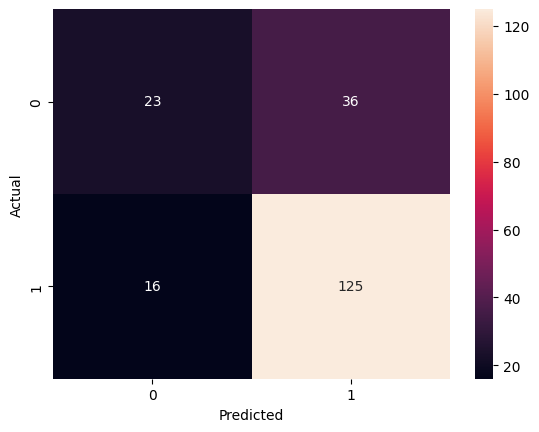

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model

rf_model = RandomForestClassifier()

# Train model

rf_model.fit(X_train, y_train)

RandomForestClassifier()

Random Forest Prediction

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf)

[1 1 0 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 1 1 1 1 0 1 1 1 1 0 0 0 1]


Random Forest Accuracy

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.755


Compare Models

In [ ]:
print("Logistic Regression Accuracy:", accuracy)

print("Random Forest Accuracy:", accuracy_rf)

Logistic Regression Accuracy: 0.74
Random Forest Accuracy: 0.755


Graph

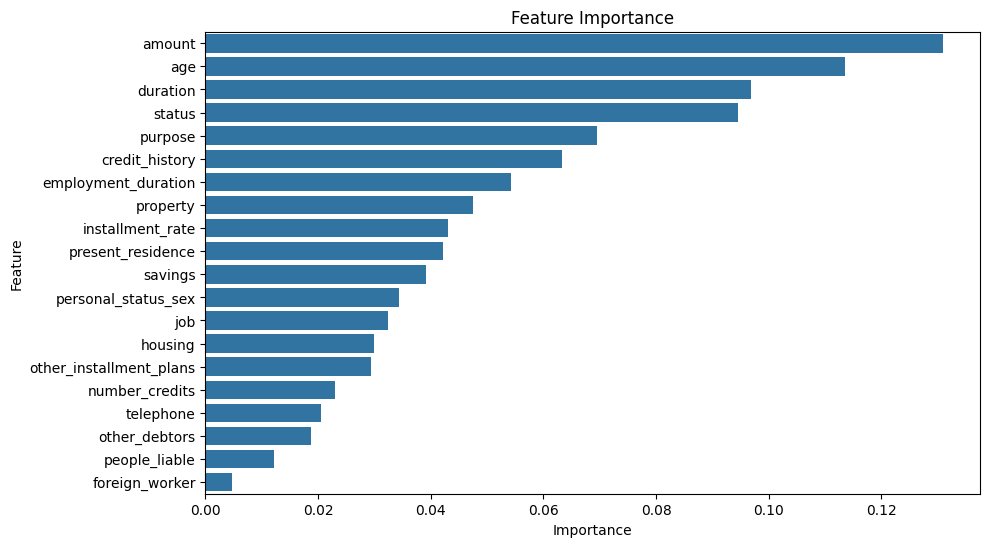

In [ ]:
importance = rf_model.feature_importances_

features = X.columns

# Create dataframe

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort

feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.show()

In [ ]:
sample = [X.iloc[0]]

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Good Credit Risk")
else:
    print("Bad Credit Risk")

Good Credit Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

joblib.dump(rf_model, 'credit_scoring_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully
